In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [3]:
import datetime
print(f"Notebook last executed(end to end):{(datetime.datetime.now())}")

Notebook last executed(end to end):2026-03-18 15:28:12.397797


creating data to view and fit (a straight line)

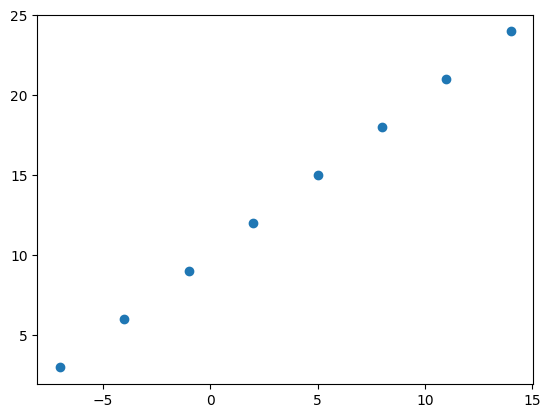

In [4]:
import numpy as np
import matplotlib.pyplot as plt
#feature
X=np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])
#label
y=np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])
plt.scatter(X,y)

In [5]:
input_shape = X[0].shape
output_shape = y[0].shape

input_shape, output_shape

((), ())

creating data with tensors

In [6]:
house_info=tf.constant(["bedroom","bathroom","garage"])
house_price=tf.constant([939700])
house_info,house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

Modeling

In [7]:
#set random seed
tf.random.set_seed(42)
#creating model
model=tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
#compiling model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])
#fitting model
model.fit(tf.expand_dims(X,axis=-1),y,epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - loss: 21.6996 - mae: 21.6996
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 21.3065 - mae: 21.3065
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 20.9134 - mae: 20.9134
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 20.5321 - mae: 20.5321
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 20.2508 - mae: 20.2508


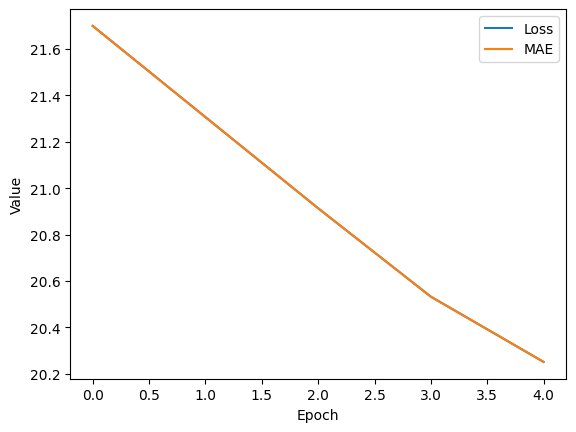

In [8]:
#plotting it
import matplotlib.pyplot as plt

plt.plot(model.history.history['loss'])
plt.plot(model.history.history['mae'])
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend(['Loss', 'MAE'])
plt.show()

checking our trained model

In [9]:
#checking values of X and y
X,y

(array([-7., -4., -1.,  2.,  5.,  8., 11., 14.]),
 array([ 3.,  6.,  9., 12., 15., 18., 21., 24.]))

In [10]:
#let's check for value of 17
x_test = tf.expand_dims([17.0], axis=-1)
model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[-23.420515]], dtype=float32)

Improving a Model

In [11]:
#tarining model for longer(everything else remains same)
tf.random.set_seed(42)

model=tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])
model.fit(tf.expand_dims(X,axis=-1),y,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - loss: 12.7084 - mae: 12.7084
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 12.5759 - mae: 12.5759
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 12.4434 - mae: 12.4434
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 12.3109 - mae: 12.3109
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 12.1784 - mae: 12.1784
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 12.0459 - mae: 12.0459
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.9134 - mae: 11.9134
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 11.7809 - mae: 11.7809
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.6484 - mae: 11.6484
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.5159 - mae: 11.5159
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 11.3834 - mae: 11.3834
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 11.2509 - mae: 11.2509
Epoch 13/100
1/1 ━━━━━━━

In [12]:
#let's check for value of 17
x_test = tf.expand_dims([17.0], axis=-1)
model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[29.68972]], dtype=float32)

Evluating a Model

In [13]:
#first making a bigger dataset
X=np.arange(-100,100,4)
X

array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])

In [14]:
#making labels
y=np.arange(-90,110,4)
y

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [15]:
#we can also make the labels like this
y=X+10
y

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

spliting data into training and test set

In [16]:
#checking how many samples we have
len(X)

50

In [17]:
#spliting data into train and test sets
X_train=X[:40]
y_train=y[:40]
X_test=X[40:]
y_test=y[40:]
len(X_train),len(X_test)

(40, 10)

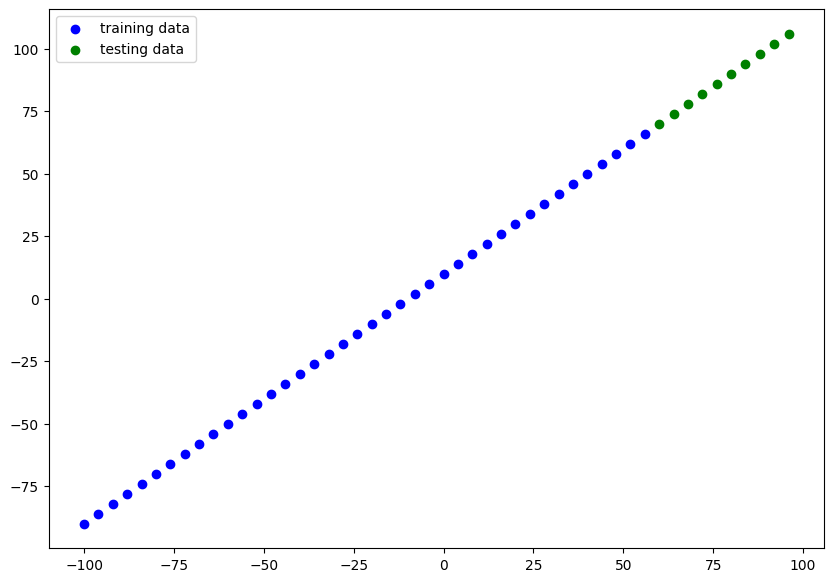

In [18]:
#Visualizing data
plt.figure(figsize=(10,7))
plt.scatter(X_train,y_train,c='b',label='training data')
plt.scatter(X_test,y_test,c='g',label='testing data')
plt.legend()


Modeling on this data

In [19]:
tf.random.set_seed(42)
#creating model
model=tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=[1])
])

#compiling model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])
#fitting model
#model.fit(tf.expand_dims(X_train,axis=-1),y_train,epochs=100)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Visualizing the model

In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Fit the model to the training data
model.fit(X_train, y_train, epochs=100, verbose=0) # verbose controls how much gets output

In [22]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

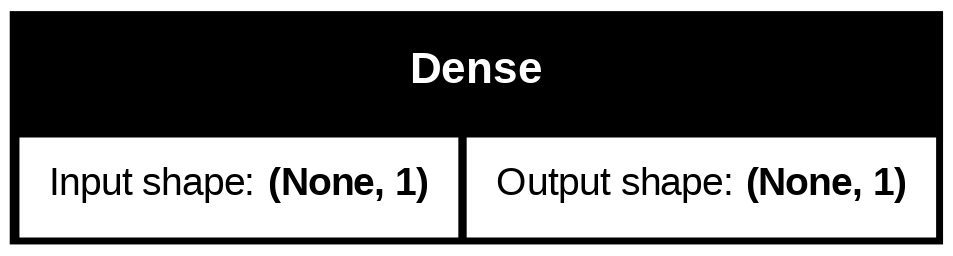

In [23]:
#viewing 2-D model of Summary
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes=True)

Visualizing the Predictions

In [24]:
#making predictions
y_preds=model.predict(X_test)
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[51.469086],
       [54.807228],
       [58.14538 ],
       [61.48352 ],
       [64.82167 ],
       [68.15981 ],
       [71.49796 ],
       [74.83611 ],
       [78.174255],
       [81.512405]], dtype=float32)

In [25]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_preds):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();

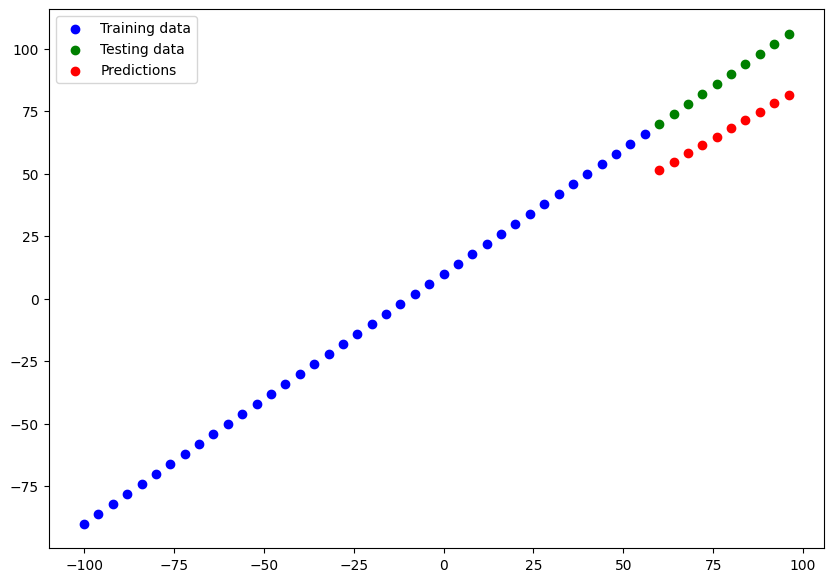

In [26]:
plot_predictions(train_data=X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_preds)

In [27]:
# Evaluate the model on the test set
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 21.5093 - mae: 21.5093


[21.509258270263672, 21.509258270263672]

In [28]:
y_preds.shape,y_test.shape

((10, 1), (10,))

In [29]:
#squeeze y_preds to make shape similar
y_preds.squeeze().shape

(10,)

In [30]:
# Calcuate the MAE
mae_metric=tf.keras.metrics.MeanAbsoluteError()
mae_metric.update_state(y_test, y_preds.squeeze())
mae = mae_metric.result().numpy()
print("MAE:", mae)



MAE: 21.509258


In [31]:
# Create the MSE metric object
mse_metric = tf.keras.metrics.MeanSquaredError()
mse_metric.update_state(y_test, y_preds.squeeze())
mse = mse_metric.result().numpy()
print("MSE:", mse)

MSE: 466.26202


In [32]:
#calculating MAE using pure tensor functions
tf.reduce_mean(tf.abs(y_test-y_preds.squeeze()))


<tf.Tensor: shape=(), dtype=float64, numpy=21.509256744384764>

In [33]:
#making functions for MAE and MSE

def mae(y_test, y_pred):
    """
    Calculates mean absolute error between y_test and y_pred.
    """
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)
    return tf.reduce_mean(tf.abs(y_test - y_pred))

def mse(y_test, y_pred):
    """
    Calculates mean squared error between y_test and y_pred.
    """
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)
    return tf.reduce_mean(tf.square(y_test - y_pred))

Running Experiments to improve a model

*building three models and compare results*

In [34]:
#model 1
tf.random.set_seed(42)
model_1=tf.keras.Sequential([
    tf.keras.layers.Dense(1)])
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])
model_1.fit(tf.expand_dims(X_train,axis=-1),y_train,epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 60.9957 - mae: 60.9957 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 26.7714 - mae: 26.7714
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.0668 - mae: 10.0668
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 11.5600 - mae: 11.5600
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.0333 - mae: 9.0333
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 10.1427 - mae: 10.1427
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 11.7071 - mae: 11.7071
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 12.5886 - mae: 12.5886
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8.3868 - mae: 8.3868
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.0655 - mae: 9.0655
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 7.8869 - mae: 7.8869
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 10.8505 - mae: 10.8505
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


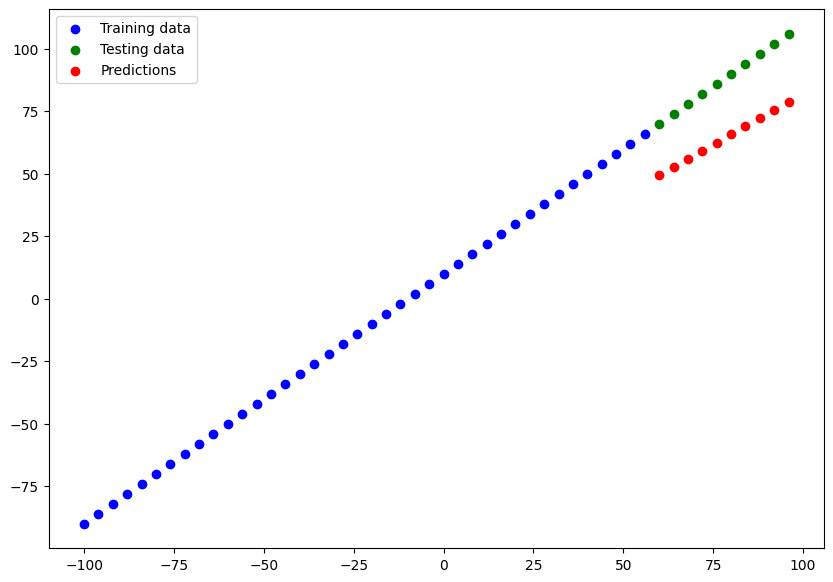

In [35]:
y_preds_1=model_1.predict(X_test)
plot_predictions(predictions=y_preds_1)

In [36]:
# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1.squeeze()).numpy()
mse_1 = mse(y_test, y_preds_1.squeeze()).numpy()
mae_1, mse_1

(np.float32(23.88596), np.float32(575.6032))

In [37]:
#model 2
# Set random seed
tf.random.set_seed(42)

# Replicate model_1 and add an extra layer
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_2.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100, verbose=0) # set verbose to 0 for less output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


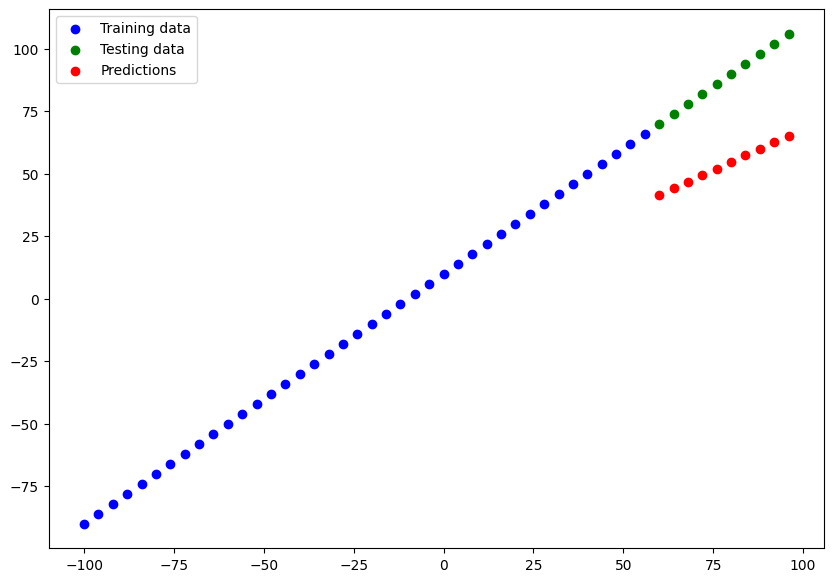

In [38]:
# Make and plot predictions for model_2
y_preds_2 = model_2.predict(X_test)
plot_predictions(predictions=y_preds_2)

In [39]:
# Calculate model_2 metrics
mae_2 = mae(y_test, y_preds_2.squeeze()).numpy()
mse_2 = mse(y_test, y_preds_2.squeeze()).numpy()
mae_2, mse_2

(np.float32(34.600185), np.float32(1212.4845))

In [40]:
#model 3
# Set random seed
tf.random.set_seed(42)

# Replicate model_2
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model (this time for 500 epochs, not 100)
model_3.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0) # set verbose to 0 for less output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


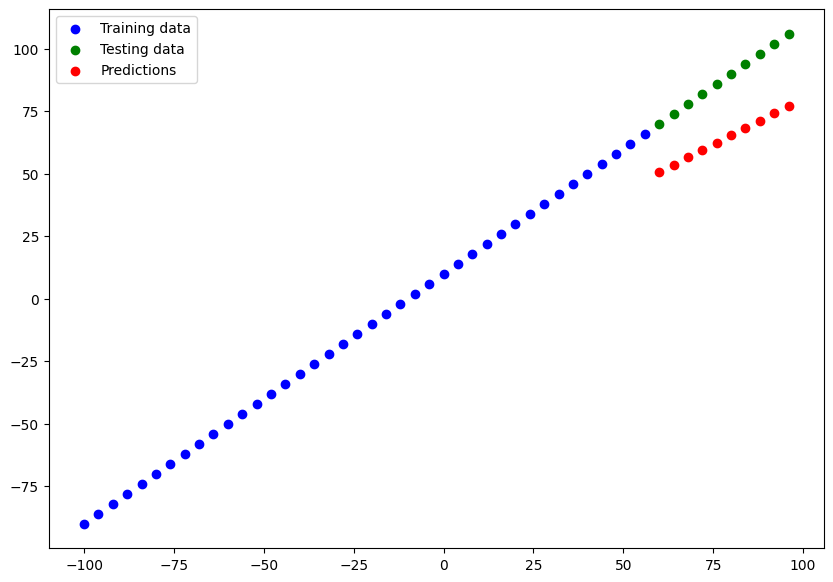

In [41]:
# Make and plot predictions for model_3
y_preds_3 = model_3.predict(X_test)
plot_predictions(predictions=y_preds_3)

In [42]:
# Calculate model_3 metrics
mae_3 = mae(y_test, y_preds_3.squeeze()).numpy()
mse_3 = mse(y_test, y_preds_3.squeeze()).numpy()
mae_3, mse_3

(np.float32(24.132118), np.float32(591.7332))

In [43]:
model_results = [["model_1", mae_1, mse_1],
                 ["model_2", mae_2, mse_2],
                 ["model_3", mae_3, mae_3]]

In [44]:
import pandas as pd
all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,23.885960,575.603210
1,model_2,34.600185,1212.484497
2,model_3,24.132118,24.132118


Saving a Model

In [46]:
model_1.export("best_model_savedmodel")

Saved artifact at 'best_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137646079666576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137646079671760: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [48]:
!ls best_model_savedmodel

assets	fingerprint.pb	saved_model.pb	variables


In [49]:
# Save in HDF5
model_1.save("best_model.h5")

In [50]:
!ls best_model.h5

best_model.h5


Loading a model

In [53]:
# Load a model from the HDF5 format
loaded_h5_model = tf.keras.models.load_model("best_model.h5")
loaded_h5_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [55]:
# Compare model_2 with the loaded HDF5 version (should return True)
h5_model_preds = loaded_h5_model.predict(X_test)
mae(y_test, h5_model_preds.squeeze()).numpy() == mae(y_test, y_preds_1.squeeze()).numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


np.True_

In [57]:
# Download the model (or any file) from Google Colab
from google.colab import files
files.download("best_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>